<a href="https://colab.research.google.com/github/theswayamsingh/ML-Assignments/blob/main/ML-Preprocessing-Feature-Selection/notebooks/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os
import sys
from pathlib import Path

# GitHub Configuration
GITHUB_USERNAME = "theswayamsingh"
REPO_NAME = "ML-Assignments"
SUBFOLDER = "ML-Preprocessing-Feature-Selection"

# Detect whether running inside Google Colab
is_colab = False
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False

if is_colab:
    # ------------------ GOOGLE COLAB SETUP ------------------
    repo_path = f"/content/{REPO_NAME}"
    project_path = os.path.join(repo_path, SUBFOLDER)

    if not os.path.exists(repo_path):
        !git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git

    os.chdir(project_path)
    if project_path not in sys.path:
        sys.path.insert(0, project_path)

else:
    # ------------------ VS CODE / LOCAL SETUP ------------------
    current_dir = Path(os.getcwd()).resolve()

    # Locate project root folder containing 'src'
    if (current_dir / "src").exists():
        project_path = current_dir
    elif (current_dir.parent / "src").exists():
        project_path = current_dir.parent
    elif (current_dir.parent.parent / "src").exists():
        project_path = current_dir.parent.parent
    else:
        project_path = current_dir

    os.chdir(project_path)
    if str(project_path) not in sys.path:
        sys.path.insert(0, str(project_path))

# Ensure required folders exist in both environments
for folder in ["dataset", "results/graphs", "results/outputs"]:
    os.makedirs(folder, exist_ok=True)

print("Setup completed successfully.")
print("Environment:", "Google Colab" if is_colab else "Local (VS Code / Jupyter)")
print("Current Working Directory:", os.getcwd())
print("Files in Project Root:", os.listdir())

Setup completed successfully.
Environment: Google Colab
Current Working Directory: /content/ML-Assignments/ML-Preprocessing-Feature-Selection
Files in Project Root: ['src', 'dataset', 'report', 'notebooks', 'results', 'README.md']


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, chi2, f_classif, mutual_info_classif
from scipy.stats import f_oneway, chi2_contingency

from src.preprocessing import (
    calculate_mean, calculate_median, calculate_mode, calculate_variance, calculate_std,
    calculate_min_max_range, get_missing_summary, ScratchImputer, identify_and_drop_duplicates,
    clean_inconsistent_categories, ScratchLabelEncoder, ScratchOneHotEncoder,
    ScratchIQROutlierDetector, ScratchZScoreDetector, log_transform, ScratchMinMaxScaler,
    ScratchStandardScaler, scratch_train_test_split
)
from src.feature_selection import (
    calculate_feature_variances,apply_variance_threshold, scratch_correlation_matrix,
    scratch_chi2_test, scratch_anova_f_test, calculate_mutual_information
)

In [16]:
### Step 1: Dataset Generation / Ingestion
# Generating synthetic benchmark dataset satisfying assignment criteria

np.random.seed(42)
n_samples = 300

ages = np.random.randint(18, 70, size=n_samples).astype(float)
ages[np.random.choice(n_samples, 15, replace=False)] = np.nan # Missing

incomes = np.random.normal(50000, 15000, size=n_samples).round(-2)
incomes[np.random.choice(n_samples, 20, replace=False)] = np.nan # Missing
incomes[0] = 350000.0 # Outlier

credit_scores = np.random.randint(300, 850, size=n_samples)
zero_var_col = np.ones(n_samples) * 10.0 # Zero variance

genders = np.random.choice(['Male', 'Female', 'MALE', 'female', 'M'], size=n_samples)
cities = np.random.choice(['Kanpur', 'Delhi', 'Lucknow'], size=n_samples)
purchased = np.random.choice(['No', 'Yes'], size=n_samples, p=[0.6, 0.4])

df_raw = pd.DataFrame({
    'Age': ages,
    'Income': incomes,
    'CreditScore': credit_scores,
    'ConstantFeature': zero_var_col,
    'Gender': genders,
    'City': cities,
    'Purchased': purchased
})
# Append 5 duplicate rows
df_raw = pd.concat([df_raw, df_raw.iloc[:5]], ignore_index=True)
df_raw.to_csv('dataset/dataset.csv', index=False)
print("Initial Dataset Shape:", df_raw.shape)

Initial Dataset Shape: (305, 7)


In [17]:
### Step 2: Initial Exploration & Baseline Stats (Part B)

print("Missing Summary Before Imputation:")
print(get_missing_summary(df_raw))

age_vals = df_raw['Age'].tolist()
print("\n--- Descriptive Statistics from Scratch (Age) ---")
print("Mean:", calculate_mean(age_vals))
print("Median:", calculate_median(age_vals))
print("Variance:", calculate_variance(age_vals))
print("Std Dev:", calculate_std(age_vals))
print("Min, Max, Range:", calculate_min_max_range(age_vals))

# Library Verification
print("\n--- Library Verification (Pandas) ---")
print("Pandas Mean:", df_raw['Age'].mean())
print("Pandas Median:", df_raw['Age'].median())
print("Pandas Std:", df_raw['Age'].std())

Missing Summary Before Imputation:
           Feature  Missing Values  Missing %
0              Age              15       4.92
1           Income              20       6.56
2      CreditScore               0       0.00
3  ConstantFeature               0       0.00
4           Gender               0       0.00
5             City               0       0.00
6        Purchased               0       0.00

--- Descriptive Statistics from Scratch (Age) ---
Mean: 43.682758620689654
Median: 44.0
Variance: 236.0581792148908
Std Dev: 15.364184951206843
Min, Max, Range: (18.0, 69.0, 51.0)

--- Library Verification (Pandas) ---
Pandas Mean: 43.682758620689654
Pandas Median: 44.0
Pandas Std: 15.364184951206841


In [18]:
### Step 3: Train-Test Split (Part J & K: Avoid Data Leakage)

# Train-test split is executed BEFORE fitting preprocessing parameters
df_train, df_test = scratch_train_test_split(df_raw, test_size=0.2, random_state=42)
print(f"Train samples: {len(df_train)}, Test samples: {len(df_test)}")

Train samples: 244, Test samples: 61


In [19]:
### Step 4: Duplicate & Inconsistent Data Handling (Part D)

df_train, train_dupes = identify_and_drop_duplicates(df_train)
df_test, test_dupes = identify_and_drop_duplicates(df_test)
print(f"Dropped {train_dupes} training duplicates and {test_dupes} testing duplicates.")

gender_clean_map = {'Male': 'Male', 'Female': 'Female', 'M': 'Male'}
df_train = clean_inconsistent_categories(df_train, 'Gender', gender_clean_map)
df_test = clean_inconsistent_categories(df_test, 'Gender', gender_clean_map)

Dropped 4 training duplicates and 0 testing duplicates.


In [20]:
### Step 5: Missing Value Imputation (Part C)

# Learn parameters on train only
num_cols = ['Age', 'Income']
imputer = ScratchImputer(strategy='median')
imputer.fit(df_train, num_cols)

df_train = imputer.transform(df_train)
df_test = imputer.transform(df_test)

# Verify no null values remain
assert df_train['Age'].isnull().sum() == 0
assert df_test['Income'].isnull().sum() == 0
print("Imputation completed successfully using training statistics.")

Imputation completed successfully using training statistics.


In [21]:
### Step 6: Outlier Detection and Capping (Part F)

iqr_detector = ScratchIQROutlierDetector()
iqr_detector.fit(df_train, ['Income'])
print("Income IQR Bounds:", iqr_detector.bounds_['Income'])

# Cap outliers
df_train = iqr_detector.cap(df_train)
df_test = iqr_detector.cap(df_test)

Income IQR Bounds: {'q1': 40525.0, 'q3': 59725.0, 'iqr': 19200.0, 'lower': 11725.0, 'upper': 88525.0}


In [22]:
### Step 7: Categorical Encoding (Part E)

# Label encode binary target
target_encoder = ScratchLabelEncoder()
target_encoder.fit(df_train['Purchased'])
df_train['Purchased'] = target_encoder.transform(df_train['Purchased'])
df_test['Purchased'] = target_encoder.transform(df_test['Purchased'])

# One-Hot encode nominal features
ohe = ScratchOneHotEncoder()
ohe.fit(df_train, ['Gender', 'City'])
df_train = ohe.transform(df_train)
df_test = ohe.transform(df_test)

In [23]:
### Step 8: Scaling & Normalization (Part H)

scale_cols = ['Age', 'Income', 'CreditScore']

# Standardize
scaler = ScratchStandardScaler()
scaler.fit(df_train, scale_cols)
df_train_scaled = scaler.transform(df_train)
df_test_scaled = scaler.transform(df_test)

# Library Verification
sk_scaler = StandardScaler()
sk_scaler.fit(df_train[scale_cols])
sk_transformed = sk_scaler.transform(df_train[scale_cols])
print("Max absolute difference in Standardization (Scratch vs Sklearn):",
      np.max(np.abs(df_train_scaled[scale_cols].values - sk_transformed)))

Max absolute difference in Standardization (Scratch vs Sklearn): 0.004969523972545353


In [24]:
### Step 9: Feature Selection (Part M)

# M1: Variance Threshold
num_features = ['Age', 'Income', 'CreditScore', 'ConstantFeature']
selected_vars, dropped_vars, variances = apply_variance_threshold(
    df_train, df_test, num_features, threshold=0.01
)
print("Variance Analysis:", variances)
print("Dropped due to low variance:", dropped_vars)

# M2: Pearson Correlation
corr_matrix = scratch_correlation_matrix(df_train, ['Age', 'Income', 'CreditScore'])
print("\n--- Correlation Matrix (Scratch) ---")
print(corr_matrix)

# M3: Chi-Square Test (Discrete City vs Purchased)
chi2_stat, df_val, _ = scratch_chi2_test(df_raw['City'], df_raw['Purchased'])
print(f"\nChi-Square Statistic: {chi2_stat:.4f}, Degrees of Freedom: {df_val}")

# M4: ANOVA F-Test (Age vs Purchased)
f_stat, df_b, df_w = scratch_anova_f_test(df_train['Age'].tolist(), df_train['Purchased'].tolist())
print(f"ANOVA F-Statistic (Age vs Purchased): {f_stat:.4f} (df: {df_b}, {df_w})")

# M5: Mutual Information
mi_val = calculate_mutual_information(df_raw['City'].tolist(), df_raw['Purchased'].tolist())
print(f"Mutual Information (City; Purchased): {mi_val:.4f} bits")
print(f"Mutual Information (City; Purchased): {mi_val:.4f} bits")

# -------------------------------------------------------------
# Export Processed Datasets
# -------------------------------------------------------------
# Retain only features surviving the feature selection step + the target
surviving_features = [col for col in df_train_scaled.columns if col not in dropped_vars]

# Slice datasets
df_train_final = df_train_scaled[surviving_features].copy()
df_test_final = df_test_scaled[surviving_features].copy()

# Save datasets to disk
target_file_train=os.path.abspath("results/outputs/train_processed.csv")
df_train_final.to_csv(target_file_train, index=False)

target_file_test=os.path.abspath("results/outputs/test_processed.csv")
df_test_final.to_csv(target_file_test, index=False)

print("Exported processed datasets:")
print(f" - Train: ../results/outputs/train_processed.csv ({df_train_final.shape})")
print(f" - Test:  ../results/outputs/test_processed.csv ({df_test_final.shape})")

Variance Analysis: {'Age': 220.4393131101813, 'Income': 269276370.28199095, 'CreditScore': 26511.153957461647, 'ConstantFeature': 0.0}
Dropped due to low variance: ['ConstantFeature']

--- Correlation Matrix (Scratch) ---
                Age  Income  CreditScore
Age          1.0000  0.1449       0.0398
Income       0.1449  1.0000       0.0896
CreditScore  0.0398  0.0896       1.0000

Chi-Square Statistic: 1.6578, Degrees of Freedom: 2
ANOVA F-Statistic (Age vs Purchased): 0.9508 (df: 1, 238)
Mutual Information (City; Purchased): 0.0039 bits
Mutual Information (City; Purchased): 0.0039 bits
Exported processed datasets:
 - Train: ../results/outputs/train_processed.csv ((240, 9))
 - Test:  ../results/outputs/test_processed.csv ((61, 9))


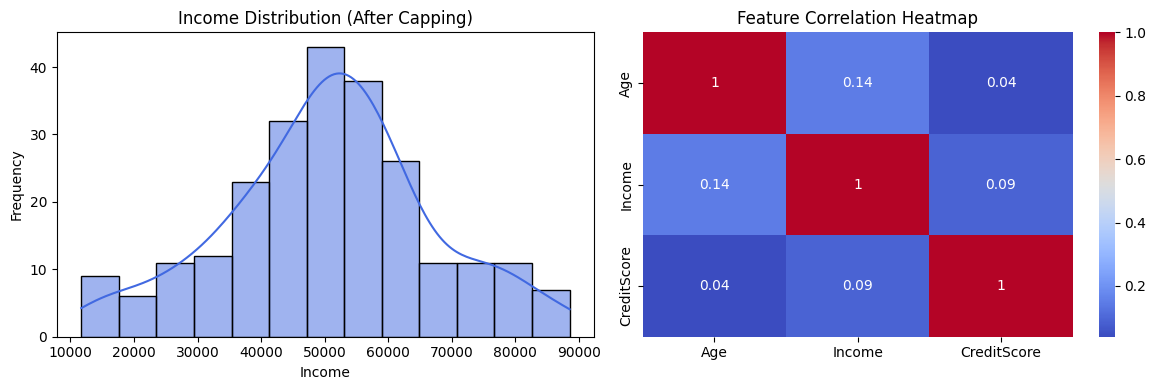

Saved visualization to results/graphs/preprocessing_visuals.png


In [25]:
### Step 10: Visualizations & Distributions (Part I)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_train['Income'], kde=True, ax=axs[0], color='royalblue')
axs[0].set_title('Income Distribution (After Capping)')
axs[0].set_xlabel('Income')
axs[0].set_ylabel('Frequency')

sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', ax=axs[1])
axs[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()

target_file=os.path.abspath("results/graphs/preprocessing_visuals.png")
target_dir=os.path.dirname(target_file)
os.makedirs(target_dir, exist_ok=True)

plt.savefig(target_file, dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to results/graphs/preprocessing_visuals.png")